# 2. Segmentaion & RFM
- H4: Different RFM segments have different retention curves
- [Next Notebook] H5: Category-diverse customers have higher retention

- **H4**: Distinct behavioral segments exist (e.g. via RFM + clustering) with **different retention curves** — not just different spend levels — meaning segment membership should drive differentiated lifecycle treatment, not just differentiated messaging.
- **[Next Notebook] H5**: **Category-diverse users (multi-merchant)** form a segment with higher loyalty/retention than single-merchant users, even after controlling for frequency — i.e., diversity of engagement is itself protective against churn, not just a byproduct of being an active user.
- **[Next Notebook] H6**: **The anonymized `feature_1/2/3` combinations** (proxy for demographic/acquisition-channel-like segments) show **statistically different engagement patterns (MANOVA)** — demonstrating you can find and validate a segment definition instead of just being handed one.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import norm,skew
from scipy import stats
import datetime as dt

import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.preprocessing import StandardScaler
from itertools import combinations
%matplotlib inline

In [2]:
rfm_churn = pd.read_csv('rfm_churn.csv')
new = pd.read_csv('new_merchant_transactions.csv')
historical = pd.read_csv('historical_transactions.csv')
merchants = pd.read_csv('merchants.csv')
transactions = pd.read_csv('transactions.csv')

In [3]:
rfm_churn.head()

,card_id,recency,frequency,monetary,r,f,m,rfm,rfm points,Tier,first_purchase_date,last_purchase_date,total_orders,total_spend,days_since_last_purchase,churned_90d,AOV,recency_days
0,C_ID_00007093c1,21 days,121,64.194000,3,4,5,345,12,High tier,2017-02-14 14:00:43,2018-02-08 16:37:19,121,64.194000,19,0,0.530529,21
1,C_ID_0001238066,2 days,113,44.172385,5,4,4,544,13,Top tier,2017-09-28 22:25:14,2018-02-27 16:18:59,113,44.172385,0,0,0.390906,2
2,C_ID_0001506ef0,12 days,66,31.398121,3,4,4,344,11,High tier,2017-01-14 16:16:01,2018-02-17 12:33:56,66,31.398121,10,0,0.475729,12
3,C_ID_0001793786,125 days,102,88.780546,1,4,5,145,10,Mid-high tier,2017-01-21 10:15:21,2017-10-27 13:51:16,102,88.780546,123,1,0.870398,125
4,C_ID_000183fdda,4 days,136,65.877791,4,5,5,455,14,Top tier,2017-08-07 09:49:14,2018-02-25 20:57:08,136,65.877791,2,0,0.484396,4


In [4]:
transactions.head()

,authorized_flag,card_id,city_id,category_1,installments,category_3,merchant_category_id,merchant_id,month_lag,purchase_amount,...,last_purchase_date,days_since_last_purchase,prev_purchase_date,next_purchase_date,gap_days,completed_gap,right_censored,followup_days,reactivated,inactivity_bin
0,Y,C_ID_00007093c1,244,N,2,C,705,M_ID_69423b34e4,-12,0.037176,...,2018-04-09 16:23:59,21,NaN,2017-02-14 15:47:45,0.074329,True,False,0.074329,1,0–1
1,Y,C_ID_00007093c1,244,N,1,B,705,M_ID_a33355a1b7,-12,-0.467415,...,2018-04-09 16:23:59,21,2017-02-14 14:00:43,2017-02-16 15:37:58,1.993206,True,False,1.993206,1,1–3
2,Y,C_ID_00007093c1,244,N,1,B,307,M_ID_9400cf2342,-12,-0.572600,...,2018-04-09 16:23:59,21,2017-02-14 15:47:45,2017-02-20 12:19:01,3.861840,True,False,3.861840,1,3–7
3,Y,C_ID_00007093c1,244,N,3,C,705,M_ID_a33355a1b7,-12,-0.331575,...,2018-04-09 16:23:59,21,2017-02-16 15:37:58,2017-03-03 00:24:15,10.503634,True,False,10.503634,1,7–14
4,Y,C_ID_00007093c1,244,N,1,B,307,M_ID_9400cf2342,-11,-0.483944,...,2018-04-09 16:23:59,21,2017-02-20 12:19:01,2017-03-06 18:50:42,3.768368,True,False,3.768368,1,3–7


In [5]:
transactions[['card_id', 'purchase_date', 'last_purchase_date', 'prev_purchase_date','next_purchase_date']][:10]

,card_id,purchase_date,last_purchase_date,prev_purchase_date,next_purchase_date
0,C_ID_00007093c1,2017-02-14 14:00:43,2018-04-09 16:23:59,NaN,2017-02-14 15:47:45
1,C_ID_00007093c1,2017-02-14 15:47:45,2018-04-09 16:23:59,2017-02-14 14:00:43,2017-02-16 15:37:58
2,C_ID_00007093c1,2017-02-16 15:37:58,2018-04-09 16:23:59,2017-02-14 15:47:45,2017-02-20 12:19:01
3,C_ID_00007093c1,2017-02-20 12:19:01,2018-04-09 16:23:59,2017-02-16 15:37:58,2017-03-03 00:24:15
4,C_ID_00007093c1,2017-03-03 00:24:15,2018-04-09 16:23:59,2017-02-20 12:19:01,2017-03-06 18:50:42
5,C_ID_00007093c1,2017-03-06 18:50:42,2018-04-09 16:23:59,2017-03-03 00:24:15,2017-03-08 15:05:29
6,C_ID_00007093c1,2017-03-08 15:05:29,2018-04-09 16:23:59,2017-03-06 18:50:42,2017-03-08 16:12:35
7,C_ID_00007093c1,2017-03-08 16:12:35,2018-04-09 16:23:59,2017-03-08 15:05:29,2017-03-11 15:04:31
8,C_ID_00007093c1,2017-03-11 15:04:31,2018-04-09 16:23:59,2017-03-08 16:12:35,2017-03-11 15:10:15
9,C_ID_00007093c1,2017-03-11 15:10:15,2018-04-09 16:23:59,2017-03-11 15:04:31,2017-03-11 15:26:58


In [6]:
transactions.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 31075392 entries, 0 to 31075391
Data columns (total 26 columns):
 #   Column                    Dtype  
---  ------                    -----  
 0   authorized_flag           object 
 1   card_id                   object 
 2   city_id                   int64  
 3   category_1                object 
 4   installments              int64  
 5   category_3                object 
 6   merchant_category_id      int64  
 7   merchant_id               object 
 8   month_lag                 int64  
 9   purchase_amount           float64
 10  purchase_date             object 
 11  category_2                float64
 12  state_id                  int64  
 13  subsector_id              int64  
 14  year                      int64  
 15  date                      object 
 16  last_purchase_date        object 
 17  days_since_last_purchase  int64  
 18  prev_purchase_date        object 
 19  next_purchase_date        object 
 20  gap_days              

# H4
H4: Distinct behavioral segments exist, based on transaction behavior such as RFM, and these segments exhibit meaningfully different retention curves—not merely different spending levels.

Business Question: Do different types of cardholders have fundamentally different lifecycle/retention patterns, and therefore require different lifecycle strategies?

Variables:
- recency_days
- frequency
- total_spend
- avg_transaction_amount
- unique_merchant_count - need to create
- category_diversity - need to create
- avg_days_between_transactions - need to create

- > RFM preprocessing: log transformation
- -> Kmean Clustering:
  > Survival analysis: Kaplan-Meier retention curves

In [9]:
historical.head()

,authorized_flag,card_id,city_id,category_1,installments,category_3,merchant_category_id,merchant_id,month_lag,purchase_amount,purchase_date,category_2,state_id,subsector_id
0,Y,C_ID_4e6213e9bc,88,N,0,A,80,M_ID_e020e9b302,-8,-0.703331,2017-06-25 15:33:07,1.0,16,37
1,Y,C_ID_4e6213e9bc,88,N,0,A,367,M_ID_86ec983688,-7,-0.733128,2017-07-15 12:10:45,1.0,16,16
2,Y,C_ID_4e6213e9bc,88,N,0,A,80,M_ID_979ed661fc,-6,-0.720386,2017-08-09 22:04:29,1.0,16,37
3,Y,C_ID_4e6213e9bc,88,N,0,A,560,M_ID_e6d5ae8ea6,-5,-0.735352,2017-09-02 10:06:26,1.0,16,34
4,Y,C_ID_4e6213e9bc,88,N,0,A,80,M_ID_e020e9b302,-11,-0.722865,2017-03-10 01:14:19,1.0,16,37


In [10]:
# unique_merchant_count 
historical['unique_merchant_count'] = (
    historical.groupby('card_id')['merchant_id']
    .transform('nunique')
)
historical['unique_merchant_count'].head()

0    55
1    55
2    55
3    55
4    55
Name: unique_merchant_count, dtype: int64

In [11]:
historical['unique_merchant_count'].value_counts()

unique_merchant_count
29     363948
31     363815
26     363401
32     363301
33     358361
        ...  
348       740
332       733
319       716
250       708
320       567
Name: count, Length: 332, dtype: int64

In [12]:
# category_diversity
historical['category_diversity'] = (
    historical.groupby('card_id')['merchant_category_id']
    .transform('nunique')
)
historical['category_diversity'].head()

0    18
1    18
2    18
3    18
4    18
Name: category_diversity, dtype: int64

In [13]:
historical['category_diversity'].value_counts()

category_diversity
21    844852
22    831105
23    827770
24    822668
20    816887
       ...  
95      1123
88      1072
86      1012
87       749
91       723
Name: count, Length: 93, dtype: int64

In [14]:
# avg_days_between_transactions
# make sure purchase_date is datetime
historical['purchase_date'] = pd.to_datetime(historical['purchase_date'])

# Sort transactions chronologically for each card
historical = historical.sort_values(['card_id', 'purchase_date'])

# Calculate days since previous transaction
historical['days_between_transactions'] = (
    historical.groupby('card_id')['purchase_date'].diff().dt.total_seconds() / (24*60*60)
)
# Calculate average days between transactions for each card
historical['avg_days_between_transactions'] = (
    historical.groupby('card_id')['days_between_transactions'].transform('mean')
)

In [15]:
historical['avg_days_between_transactions'].describe()

count    2.911236e+07
mean     2.805215e+00
std      3.477135e+00
min      5.123309e-02
25%      1.026623e+00
50%      1.773130e+00
75%      3.235568e+00
max      2.598148e+02
Name: avg_days_between_transactions, dtype: float64

In [16]:
historical.head()

,authorized_flag,card_id,city_id,category_1,installments,category_3,merchant_category_id,merchant_id,month_lag,purchase_amount,purchase_date,category_2,state_id,subsector_id,unique_merchant_count,category_diversity,days_between_transactions,avg_days_between_transactions
19095896,Y,C_ID_00007093c1,244,N,2,C,705,M_ID_69423b34e4,-12,0.037176,2017-02-14 14:00:43,3.0,2,33,29,18,NaN,2.551587
19095775,Y,C_ID_00007093c1,244,N,1,B,705,M_ID_a33355a1b7,-12,-0.467415,2017-02-14 15:47:45,3.0,2,33,29,18,0.074329,2.551587
19095845,Y,C_ID_00007093c1,244,N,1,B,307,M_ID_9400cf2342,-12,-0.572600,2017-02-16 15:37:58,3.0,2,19,29,18,1.993206,2.551587
19095866,Y,C_ID_00007093c1,244,N,3,C,705,M_ID_a33355a1b7,-12,-0.331575,2017-02-20 12:19:01,3.0,2,33,29,18,3.861840,2.551587
19095808,Y,C_ID_00007093c1,244,N,1,B,307,M_ID_9400cf2342,-11,-0.483944,2017-03-03 00:24:15,3.0,2,19,29,18,10.503634,2.551587


In [17]:
historical_new_columns = historical[['card_id','unique_merchant_count','category_diversity','avg_days_between_transactions']]
rfm_churn = pd.merge(rfm_churn, historical_new_columns, on='card_id', how='outer')
rfm_churn.head()

,card_id,recency,frequency,monetary,r,f,m,rfm,rfm points,Tier,...,last_purchase_date,total_orders,total_spend,days_since_last_purchase,churned_90d,AOV,recency_days,unique_merchant_count,category_diversity,avg_days_between_transactions
0,C_ID_00007093c1,21 days,121.0,64.194,3.0,4.0,5.0,345.0,12.0,High tier,...,2018-02-08 16:37:19,121.0,64.194,19.0,0.0,0.530529,21.0,29,18,2.551587
1,C_ID_00007093c1,21 days,121.0,64.194,3.0,4.0,5.0,345.0,12.0,High tier,...,2018-02-08 16:37:19,121.0,64.194,19.0,0.0,0.530529,21.0,29,18,2.551587
2,C_ID_00007093c1,21 days,121.0,64.194,3.0,4.0,5.0,345.0,12.0,High tier,...,2018-02-08 16:37:19,121.0,64.194,19.0,0.0,0.530529,21.0,29,18,2.551587
3,C_ID_00007093c1,21 days,121.0,64.194,3.0,4.0,5.0,345.0,12.0,High tier,...,2018-02-08 16:37:19,121.0,64.194,19.0,0.0,0.530529,21.0,29,18,2.551587
4,C_ID_00007093c1,21 days,121.0,64.194,3.0,4.0,5.0,345.0,12.0,High tier,...,2018-02-08 16:37:19,121.0,64.194,19.0,0.0,0.530529,21.0,29,18,2.551587


In [19]:
rfm_churn.describe()

,frequency,monetary,r,f,m,rfm,rfm points,total_orders,total_spend,days_since_last_purchase,churned_90d,AOV,recency_days,unique_merchant_count,category_diversity,avg_days_between_transactions
count,2.896017e+07,2.896017e+07,2.896017e+07,2.896017e+07,2.896017e+07,2.896017e+07,2.896017e+07,2.896017e+07,2.896017e+07,2.896017e+07,2.896017e+07,2.896017e+07,2.896017e+07,2.911236e+07,2.911236e+07,2.911236e+07
mean,1.958518e+02,1.537837e+02,3.472276e+00,4.140656e+00,4.098775e+00,3.927329e+02,1.171171e+01,1.958518e+02,1.537837e+02,3.315283e+01,1.285767e-01,1.037763e+00,3.514572e+01,6.477481e+01,2.899135e+01,2.805215e+00
std,1.904708e+02,4.333447e+03,1.433780e+00,1.161369e+00,1.177850e+00,1.479050e+02,3.064280e+00,1.904708e+02,4.333447e+03,6.397420e+01,3.347309e-01,3.230285e+02,6.396627e+01,4.809657e+01,1.446817e+01,3.477135e+00
min,1.000000e+00,2.531072e-01,1.000000e+00,1.000000e+00,1.000000e+00,1.110000e+02,3.000000e+00,1.000000e+00,2.531072e-01,-1.000000e+00,0.000000e+00,2.531072e-01,1.000000e+00,1.000000e+00,1.000000e+00,5.123309e-02
25%,6.600000e+01,2.565121e+01,2.000000e+00,4.000000e+00,3.000000e+00,2.550000e+02,1.000000e+01,6.600000e+01,2.565121e+01,-1.000000e+00,0.000000e+00,3.168966e-01,1.000000e+00,3.000000e+01,1.800000e+01,1.026623e+00
50%,1.370000e+02,5.274049e+01,4.000000e+00,5.000000e+00,5.000000e+00,4.440000e+02,1.200000e+01,1.370000e+02,5.274049e+01,4.000000e+00,0.000000e+00,3.604727e-01,6.000000e+00,5.200000e+01,2.700000e+01,1.773130e+00
75%,2.640000e+02,1.022122e+02,5.000000e+00,5.000000e+00,5.000000e+00,5.540000e+02,1.400000e+01,2.640000e+02,1.022122e+02,3.100000e+01,0.000000e+00,4.398293e-01,3.300000e+01,8.700000e+01,3.800000e+01,3.235568e+00
max,2.889000e+03,6.010608e+06,5.000000e+00,5.000000e+00,5.000000e+00,5.550000e+02,1.500000e+01,2.889000e+03,6.010608e+06,4.220000e+02,1.000000e+00,5.008840e+05,4.240000e+02,4.250000e+02,9.500000e+01,2.598148e+02


### RFM Preprocessing

In [21]:
# Perform log transaformation for 'frequency', 'monetary', 'total_orders', 'total_spend', 'AOV', 'recency_days', 
# 'days_since_last_purchase', 'unique_merchant_count', 'category_diversity', 'avg_days_between_transactions'

def log_transform(df, cols):
    log_cols = []
    
    for col in cols:
        log_col = f'{col}_log'
        df[log_col] = np.log1p(df[col])
        log_cols.append(log_col)
    return df, log_cols

In [22]:
columns = ['frequency', 'monetary', 'total_orders', 'total_spend', 'AOV', 'recency_days', 'days_since_last_purchase', 'unique_merchant_count', 'category_diversity', 'avg_days_between_transactions']
log_transform(rfm_churn, columns)

/opt/anaconda3/lib/python3.12/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)


(                  card_id  recency  frequency   monetary    r    f    m  \
 0         C_ID_00007093c1  21 days      121.0  64.194000  3.0  4.0  5.0   
 1         C_ID_00007093c1  21 days      121.0  64.194000  3.0  4.0  5.0   
 2         C_ID_00007093c1  21 days      121.0  64.194000  3.0  4.0  5.0   
 3         C_ID_00007093c1  21 days      121.0  64.194000  3.0  4.0  5.0   
 4         C_ID_00007093c1  21 days      121.0  64.194000  3.0  4.0  5.0   
 ...                   ...      ...        ...        ...  ...  ...  ...   
 29112356  C_ID_fffffd5772   4 days       42.0  13.888041  4.0  3.0  2.0   
 29112357  C_ID_fffffd5772   4 days       42.0  13.888041  4.0  3.0  2.0   
 29112358  C_ID_fffffd5772   4 days       42.0  13.888041  4.0  3.0  2.0   
 29112359  C_ID_fffffd5772   4 days       42.0  13.888041  4.0  3.0  2.0   
 29112360  C_ID_fffffd5772   4 days       42.0  13.888041  4.0  3.0  2.0   
 
             rfm  rfm points           Tier  ... frequency_log monetary_log  \
 0     

In [23]:
rfm_churn.head()

,card_id,recency,frequency,monetary,r,f,m,rfm,rfm points,Tier,...,frequency_log,monetary_log,total_orders_log,total_spend_log,AOV_log,recency_days_log,days_since_last_purchase_log,unique_merchant_count_log,category_diversity_log,avg_days_between_transactions_log
0,C_ID_00007093c1,21 days,121.0,64.194,3.0,4.0,5.0,345.0,12.0,High tier,...,4.804021,4.177367,4.804021,4.177367,0.425613,3.091042,2.995732,3.401197,2.944439,1.267395
1,C_ID_00007093c1,21 days,121.0,64.194,3.0,4.0,5.0,345.0,12.0,High tier,...,4.804021,4.177367,4.804021,4.177367,0.425613,3.091042,2.995732,3.401197,2.944439,1.267395
2,C_ID_00007093c1,21 days,121.0,64.194,3.0,4.0,5.0,345.0,12.0,High tier,...,4.804021,4.177367,4.804021,4.177367,0.425613,3.091042,2.995732,3.401197,2.944439,1.267395
3,C_ID_00007093c1,21 days,121.0,64.194,3.0,4.0,5.0,345.0,12.0,High tier,...,4.804021,4.177367,4.804021,4.177367,0.425613,3.091042,2.995732,3.401197,2.944439,1.267395
4,C_ID_00007093c1,21 days,121.0,64.194,3.0,4.0,5.0,345.0,12.0,High tier,...,4.804021,4.177367,4.804021,4.177367,0.425613,3.091042,2.995732,3.401197,2.944439,1.267395


### Kmean Clustering:

In [25]:
# Check infinity
features_check = ['frequency_log',
  'monetary_log',
  'total_orders_log',
  'total_spend_log',
  'AOV_log',
  'recency_days_log',
  'days_since_last_purchase_log',
  'unique_merchant_count_log',
  'category_diversity_log',
  'avg_days_between_transactions_log']

np.isinf(rfm_churn[features_check]).sum()

frequency_log                              0
monetary_log                               0
total_orders_log                           0
total_spend_log                            0
AOV_log                                    0
recency_days_log                           0
days_since_last_purchase_log         7529522
unique_merchant_count_log                  0
category_diversity_log                     0
avg_days_between_transactions_log          0
dtype: int64

In [26]:
rfm_churn['days_since_last_purchase'].value_counts().head(20)

days_since_last_purchase
-1.0     7529522
 0.0     2929155
 1.0     1624026
 3.0     1186369
 2.0     1120300
 4.0      863524
 5.0      619060
 27.0     606008
 6.0      541437
 7.0      481169
 10.0     387547
 8.0      375066
 58.0     336695
 11.0     297750
 9.0      297352
 28.0     285246
 12.0     272929
 89.0     252430
 59.0     244262
 13.0     209924
Name: count, dtype: int64

In [27]:
# Standardize before modeling
# K-Means: standardization is essential as K-Means groups observations based on distance and is sensitive to scale!!
# Excluding 'days_since_last_purchase_log' here as it contains negative log
features = ['frequency_log',
  'monetary_log',
  'total_orders_log',
  'total_spend_log',
  'AOV_log',
  'recency_days_log',
  # 'days_since_last_purchase_log',
  'unique_merchant_count_log',
  'category_diversity_log',
  'avg_days_between_transactions_log']

In [28]:
# Check NaNs in the original clustering features
rfm_churn[features].isna().sum()

frequency_log                        152187
monetary_log                         152187
total_orders_log                     152187
total_spend_log                      152187
AOV_log                              152187
recency_days_log                     152187
unique_merchant_count_log                 0
category_diversity_log                    0
avg_days_between_transactions_log         0
dtype: int64

In [29]:
# drop na
X_kmeans = rfm_churn[features].dropna()

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X_kmeans)

In [30]:
print("NaN:", np.isnan(X_scaled).sum())
print("Inf:", np.isinf(X_scaled).sum())

NaN: 0
Inf: 0


In [31]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# Sample once so every k is evaluated on the same observations
sample_size = min(10000, len(X_scaled))

rng = np.random.default_rng(42)
sample_idx = rng.choice(
    len(X_scaled),
    size=sample_size,
    replace=False
)

X_sample = X_scaled[sample_idx]

results = []

for k in range(2, 8):

    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    # Fit KMeans on the full dataset
    labels = model.fit_predict(X_scaled)

    # Get labels for the sample
    sample_labels = model.predict(X_sample)

    # Calculate silhouette only on the sample
    score = silhouette_score(
        X_sample,
        sample_labels
    )

    results.append({
        "k": k,
        "silhouette": score
    })

results

[{'k': 2, 'silhouette': 0.39075475273333693},
 {'k': 3, 'silhouette': 0.3029576393034598},
 {'k': 4, 'silhouette': 0.31591677008313845},
 {'k': 5, 'silhouette': 0.2554207926017163},
 {'k': 6, 'silhouette': 0.266423750398224},
 {'k': 7, 'silhouette': 0.2376837012471156}]

--> based on silhouette score, k=2 is clearly the winner.

In [33]:
best_k = 2

final_model = KMeans(
    n_clusters=best_k,
    random_state=42,
    n_init=10
)

final_labels = final_model.fit_predict(X_scaled)

In [34]:
final_labels[:10]

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0], dtype=int32)

In [35]:
len(final_labels)

28960174

Visualize the result using PCA

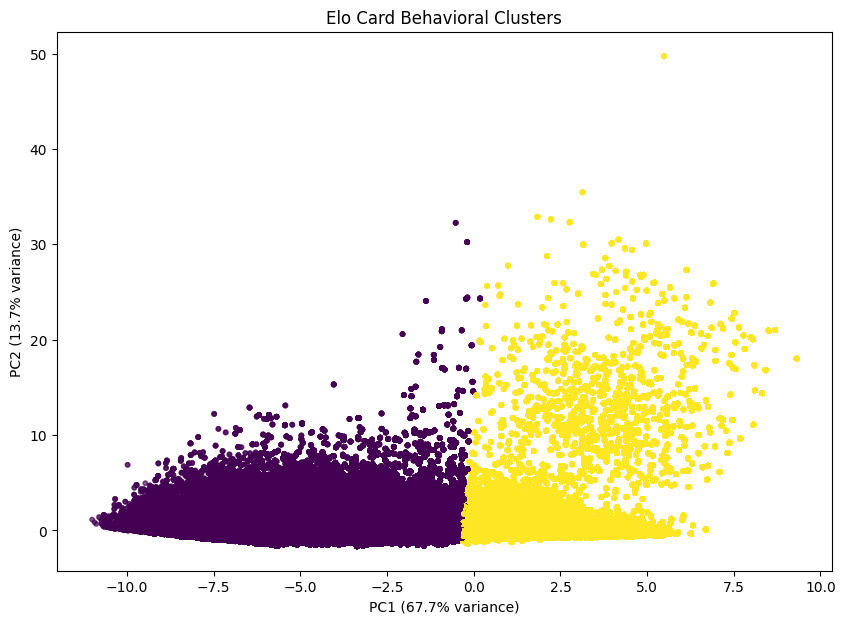

In [37]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2, random_state=42)

X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(10, 7))

plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=final_labels,
    alpha=0.4,
    s=10
)

plt.xlabel(
    f"PC1 ({pca.explained_variance_ratio_[0] * 100:.1f}% variance)"
)

plt.ylabel(
    f"PC2 ({pca.explained_variance_ratio_[1] * 100:.1f}% variance)"
)

plt.title("Elo Card Behavioral Clusters")
plt.show()

In [38]:
# Add cluster labels to X_kmeans
X_kmeans = X_kmeans.copy()
X_kmeans['cluster'] = final_labels

In [39]:
X_kmeans['cluster'].value_counts()

cluster
1    16791751
0    12168423
Name: count, dtype: int64

In [40]:
X_kmeans.head()

,frequency_log,monetary_log,total_orders_log,total_spend_log,AOV_log,recency_days_log,unique_merchant_count_log,category_diversity_log,avg_days_between_transactions_log,cluster
0,4.804021,4.177367,4.804021,4.177367,0.425613,3.091042,3.401197,2.944439,1.267395,0
1,4.804021,4.177367,4.804021,4.177367,0.425613,3.091042,3.401197,2.944439,1.267395,0
2,4.804021,4.177367,4.804021,4.177367,0.425613,3.091042,3.401197,2.944439,1.267395,0
3,4.804021,4.177367,4.804021,4.177367,0.425613,3.091042,3.401197,2.944439,1.267395,0
4,4.804021,4.177367,4.804021,4.177367,0.425613,3.091042,3.401197,2.944439,1.267395,0


In [41]:
X_kmeans.groupby("cluster")[['frequency_log', 'monetary_log','total_orders_log','total_spend_log','AOV_log','recency_days_log', 'unique_merchant_count_log', 'category_diversity_log','avg_days_between_transactions_log']].mean()

,frequency_log,monetary_log,total_orders_log,total_spend_log,AOV_log,recency_days_log,unique_merchant_count_log,category_diversity_log,avg_days_between_transactions_log
cluster,,,,,,,,,
0,3.890293,3.018689,3.890293,3.018689,0.353167,2.951938,3.268450,2.829288,1.576991
1,5.516971,4.610191,5.516971,4.610191,0.361946,1.884479,4.411802,3.602456,0.804428


- **Cluster 1:** low frquency, low monetary value, less recent, less unique merchant and category
- -> **Lower-engagement / less-active cards**
- **Cluster 2:** more frequent, larger monetary value (esp. ttl spending; similar AOV to Cluster 1), more recent, more unique merchant & cateory
- -> **Higher-engagement / more-active cards**

In [43]:
# X_kmeans.groupby('cluster')[features].mean().T

### Segment the result and label, then merge with card_id and churn falg

In [104]:
# Keep ID + cluster assignment
rfm_churn_dropna = rfm_churn.dropna()
cluster_assignments = rfm_churn_dropna[['card_id']].copy()
cluster_assignments.head()

,card_id
0,C_ID_00007093c1
1,C_ID_00007093c1
2,C_ID_00007093c1
3,C_ID_00007093c1
4,C_ID_00007093c1


In [105]:
cluster_assignments['cluster'] = final_labels
# merge to survival_df
survival_rfm_churn = rfm_churn_dropna[['card_id', 'churned_90d']].copy()

In [106]:
print("survival_rfm_churn:", survival_rfm_churn.shape)
print("cluster_assignments:", cluster_assignments.shape)
print(
    "duplicate card_ids in survival:",
    survival_rfm_churn['card_id'].duplicated().sum()
)

print(
    "duplicate card_ids in clusters:",
    cluster_assignments['card_id'].duplicated().sum()
)

survival_rfm_churn: (28960174, 2)
cluster_assignments: (28960174, 2)
duplicate card_ids in survival: 28640515
duplicate card_ids in clusters: 28640515


In [107]:
cluster_assignments['card_id'].duplicated().sum()

28640515

In [108]:
cluster_assignments['card_id'].nunique()

319659

In [109]:
len(cluster_assignments)

28960174

In [110]:
cluster_assignments[
    cluster_assignments['card_id'].duplicated(keep=False)
].sort_values('card_id').head(20)

,card_id,cluster
0,C_ID_00007093c1,0
96,C_ID_00007093c1,0
97,C_ID_00007093c1,0
98,C_ID_00007093c1,0
99,C_ID_00007093c1,0
100,C_ID_00007093c1,0
101,C_ID_00007093c1,0
95,C_ID_00007093c1,0
102,C_ID_00007093c1,0
105,C_ID_00007093c1,0


In [111]:
# --> need to deduplicate cluster_assignments
cluster_assignments_unique = (
    cluster_assignments[
        ['card_id', 'cluster']
    ]
    .drop_duplicates('card_id')
)

In [112]:
# --> need to deduplicate survival_rfm_churn
survival_rfm_churn_unique = (
    survival_rfm_churn[
        ['card_id', 'churned_90d']
    ]
    .drop_duplicates('card_id')
)

In [113]:
print(cluster_assignments_unique.shape)
print(cluster_assignments_unique['card_id'].nunique())

(319659, 2)
319659


In [114]:
# merge survival_rfm_churn and cluster_assignments_unique (deduplicated)
survival_rfm_churn_unique = survival_rfm_churn_unique.merge(
    cluster_assignments_unique,
    on='card_id',
    how='left')

In [115]:
survival_rfm_churn_unique[:5]

,card_id,churned_90d,cluster
0,C_ID_00007093c1,0.0,0
1,C_ID_0001238066,0.0,1
2,C_ID_0001506ef0,0.0,0
3,C_ID_0001793786,1.0,1
4,C_ID_000183fdda,0.0,1


## Survival Analysis by cluster

In [141]:
segment_counts = (
    survival_rfm_churn_unique
    .groupby(['churned_90d', 'cluster'])
    .size()
    .reset_index(name='count')
)
segment_counts['pct_of_total'] = (
    (segment_counts['count'] / len(survival_rfm_churn_unique) * 100).round(4)
)

segment_counts

,churned_90d,cluster,count,pct_of_total
0,0.0,0,191330,59.8544
1,0.0,1,66494,20.8015
2,1.0,0,55587,17.3895
3,1.0,1,6248,1.9546


In [143]:
transactions['purchase_date'] = pd.to_datetime(
    transactions['purchase_date']
)
print(f'dataatype:', transactions['purchase_date'].dtype)
transactions['purchase_date'].max()

dataatype: datetime64[ns]


Timestamp('2018-04-30 23:59:59')

In [145]:
# construct card_id level transaction churn date column

card_dates = (
    transactions
    .groupby('card_id')
    .agg(
        first_purchase_date=('purchase_date', 'min'),
        last_purchase_date=('purchase_date', 'max')
    )
    .reset_index()
)

# churn_date = last_purchase_date + 90 days
observation_end = pd.Timestamp('2018-04-30 23:59:59')

card_survival = card_dates.copy()

card_survival['churn_date'] = (
    card_survival['last_purchase_date']
    + pd.Timedelta(days=90)
)

card_survival['churned_90d'] = (
    card_survival['churn_date'] <= observation_end
).astype(int)

card_survival.head()

,card_id,first_purchase_date,last_purchase_date,churn_date,churned_90d
0,C_ID_00007093c1,2017-02-14 14:00:43,2018-04-09 16:23:59,2018-07-08 16:23:59,0
1,C_ID_0001238066,2017-09-28 22:25:14,2018-04-30 19:57:30,2018-07-29 19:57:30,0
2,C_ID_0001506ef0,2017-01-14 16:16:01,2018-03-22 09:14:30,2018-06-20 09:14:30,0
3,C_ID_0001793786,2017-01-21 10:15:21,2017-12-31 17:35:56,2018-03-31 17:35:56,1
4,C_ID_000183fdda,2017-08-07 09:49:14,2018-04-30 14:59:53,2018-07-29 14:59:53,0


In [147]:
# construct duration date:
# duration = churn date - baseline date for churned card
# duration = observation end - baseline date for non-churned card

# baseline date = cutoff date (90days) = the starting point of the survival analysis
baseline_date = pd.Timestamp('2018-01-31')

# event_date = when you stop observing the customer
card_survival['event_date'] = np.where(
    card_survival['churned_90d'] == 1,
    card_survival['churn_date'],
    observation_end
)

card_survival['event_date'] = pd.to_datetime(
    card_survival['event_date']
)

card_survival['duration_days'] = (
    card_survival['event_date'] - baseline_date
).dt.days

# Survival(KM) Analysis starts from 2018-01-31 so only include these dates
card_survival_at_risk = card_survival[
    card_survival['churn_date'] > baseline_date
].copy()

In [149]:
card_survival_at_risk.head()

,card_id,first_purchase_date,last_purchase_date,churn_date,churned_90d,event_date,duration_days
0,C_ID_00007093c1,2017-02-14 14:00:43,2018-04-09 16:23:59,2018-07-08 16:23:59,0,2018-04-30 23:59:59,89
1,C_ID_0001238066,2017-09-28 22:25:14,2018-04-30 19:57:30,2018-07-29 19:57:30,0,2018-04-30 23:59:59,89
2,C_ID_0001506ef0,2017-01-14 16:16:01,2018-03-22 09:14:30,2018-06-20 09:14:30,0,2018-04-30 23:59:59,89
3,C_ID_0001793786,2017-01-21 10:15:21,2017-12-31 17:35:56,2018-03-31 17:35:56,1,2018-03-31 17:35:56,59
4,C_ID_000183fdda,2017-08-07 09:49:14,2018-04-30 14:59:53,2018-07-29 14:59:53,0,2018-04-30 23:59:59,89


In [151]:
print(f'ttl duration_days count:', len(card_survival_at_risk['duration_days']))
card_survival_at_risk.describe()

ttl duration_days count: 296522


,first_purchase_date,last_purchase_date,churn_date,churned_90d,event_date,duration_days
count,296522,296522,296522,296522.000000,296522,296522.000000
mean,2017-05-24 05:43:33.453065984,2018-03-24 10:40:12.191392256,2018-06-22 10:40:12.191392256,0.120396,2018-04-26 19:14:56.165579264,84.851593
min,2017-01-01 00:00:08,2017-11-02 00:08:31,2018-01-31 00:08:31,0.000000,2018-01-31 00:08:31,0.000000
25%,2017-01-18 11:45:51.500000,2018-03-01 18:40:26.500000,2018-05-30 18:40:26.500000,0.000000,2018-04-30 23:59:59,89.000000
50%,2017-05-14 12:42:26,2018-04-08 22:37:33,2018-07-07 22:37:33,0.000000,2018-04-30 23:59:59,89.000000
75%,2017-09-09 13:39:36.750000128,2018-04-24 18:31:50,2018-07-23 18:31:50,0.000000,2018-04-30 23:59:59,89.000000
max,2017-12-31 23:38:15,2018-04-30 23:59:59,2018-07-29 23:59:59,1.000000,2018-04-30 23:59:59,89.000000
std,NaN,NaN,NaN,0.325424,NaN,14.158525


In [153]:
card_survival_at_risk['card_id'].nunique()

296522

In [155]:
survival_rfm_churn_unique['card_id'].nunique()

319659

card_survival_at_risk dropped the churned card before baseline_date = '2018-01-31', the time when the survival analysis starts

In [157]:
# merge survival_rfm_churn and cluster_assignments_unique (deduplicated)
survival_rfm_churn_unique = survival_rfm_churn_unique.merge(
    card_survival_at_risk,
    on='card_id',
    how='inner')

In [159]:
print(f'shape of survival_rfm_churn_unique:', survival_rfm_churn_unique.shape)
survival_rfm_churn_unique.head()

shape of survival_rfm_churn_unique: (291631, 9)


,card_id,churned_90d_x,cluster,first_purchase_date,last_purchase_date,churn_date,churned_90d_y,event_date,duration_days
0,C_ID_00007093c1,0.0,0,2017-02-14 14:00:43,2018-04-09 16:23:59,2018-07-08 16:23:59,0,2018-04-30 23:59:59,89
1,C_ID_0001238066,0.0,1,2017-09-28 22:25:14,2018-04-30 19:57:30,2018-07-29 19:57:30,0,2018-04-30 23:59:59,89
2,C_ID_0001506ef0,0.0,0,2017-01-14 16:16:01,2018-03-22 09:14:30,2018-06-20 09:14:30,0,2018-04-30 23:59:59,89
3,C_ID_0001793786,1.0,1,2017-01-21 10:15:21,2017-12-31 17:35:56,2018-03-31 17:35:56,1,2018-03-31 17:35:56,59
4,C_ID_000183fdda,0.0,1,2017-08-07 09:49:14,2018-04-30 14:59:53,2018-07-29 14:59:53,0,2018-04-30 23:59:59,89


In [172]:
# perform survival analysis for Cluster 0 anad 1
from lifelines import KaplanMeierFitter


def perform_kmf_cluster(df, cluster_id, duration_col='duration_days',
                        event_col='churned_90d_x'):
    """
    Perform Kaplan-Meier survival analysis for a specific K-means cluster.

    Parameters
    ----------
    df : pandas.DataFrame
        Dataset containing cluster, duration, and event information.

    cluster_id : int
        Cluster to analyze (e.g., 0 or 1).

    duration_col : str
        Column containing survival/follow-up duration.

    event_col : str
        Column indicating the event:
        1 = churned/event occurred
        0 = censored/no churn observed

    Returns
    -------
    kmf : KaplanMeierFitter
        Fitted Kaplan-Meier model.

    cluster_df : pandas.DataFrame
        Data used for the survival analysis.
    """

    # 1. Select the requested cluster
    cluster_df = df[df['cluster'] == cluster_id].copy()

    # 2. Remove missing survival information
    cluster_df = cluster_df.dropna(
        subset=[duration_col, event_col]
    )

    # 3. Fit Kaplan-Meier model
    kmf = KaplanMeierFitter()

    kmf.fit(
        durations=cluster_df[duration_col],
        event_observed=cluster_df[event_col],
        label=f'Cluster {cluster_id}'
    )

    return kmf, cluster_df

In [174]:
# For Cluster 0 = Lower-engagement / less-active cards
kmf_0, cluster_0_df = perform_kmf_cluster(
    survival_rfm_churn_unique,
    cluster_id=0,
    duration_col='duration_days',
    event_col='churned_90d_x'
)

In [184]:
# For Cluster 1 = Higher-engagement / more-active cards
kmf_1, cluster_1_df = perform_kmf_cluster(
    survival_rfm_churn_unique,
    cluster_id=1,
    duration_col='duration_days',
    event_col='churned_90d_x'
)

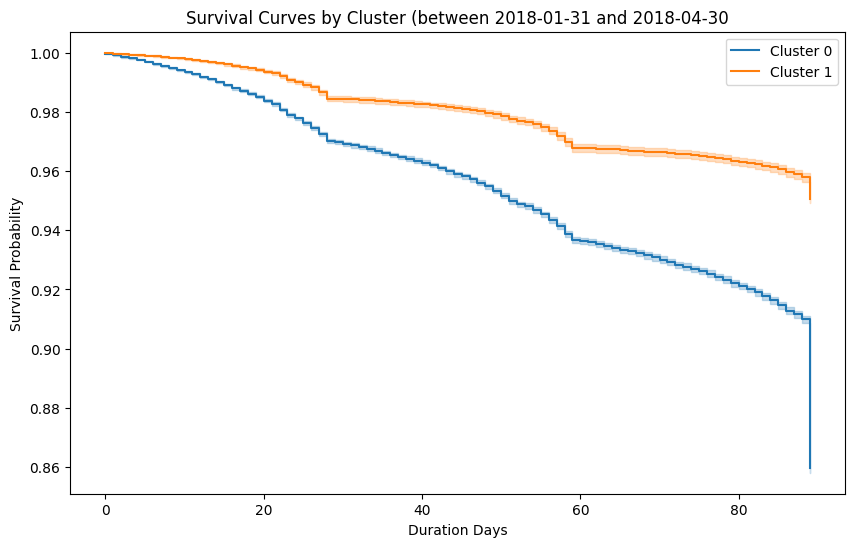

In [190]:
# plot it together
plt.figure(figsize=(10, 6))

kmf_0.plot_survival_function()
kmf_1.plot_survival_function()

plt.title('Survival Curves by Cluster (between 2018-01-31 and 2018-04-30)')
plt.xlabel('Duration Days')
plt.ylabel('Survival Probability')
plt.legend()

plt.show()

## Appendix: for H4 - Kmeans=4

In [ ]:
# Kmeans with4 cluster
best_k = 4

final_model_4 = KMeans(
    n_clusters=best_k,
    random_state=42,
    n_init=10
)

final_labels_4 = final_model_4.fit_predict(X_scaled)

In [ ]:
X_kmeans_4 = X_kmeans.copy()
X_kmeans_4['cluster'] = final_labels_4

In [ ]:
X_kmeans_4.groupby("cluster")[['frequency_log', 'monetary_log','total_orders_log','total_spend_log','AOV_log','recency_days_log', 'unique_merchant_count_log', 'category_diversity_log','avg_days_between_transactions_log']].mean()

In [ ]:
# test kmeans 2 vs 4
from sklearn.cluster import KMeans
import pandas as pd

def fit_kmeans(X_scaled, k):

    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = model.fit_predict(X_scaled)

    counts = (
        pd.Series(labels)
        .value_counts()
        .sort_index()
    )

    profile = pd.DataFrame({
        "cluster": counts.index,
        "n_cards": counts.values,
        "pct_cards": (
            counts.values / len(labels) * 100
        ).round(2)
    })

    return model, labels, profile

In [ ]:
model_2, labels_2, profile_2 = fit_kmeans(
    X_scaled,
    2
)

model_4, labels_4, profile_4 = fit_kmeans(
    X_scaled,
    4
)

In [ ]:
profile_2

In [ ]:
profile_4

---> cluster 3 of Kmeans4 only accounts for 0.51% of the cluster but has higher monetary value(ttl spending and aov) than cluster 0-2. this eans a smaller nuebr of customers are spending disproportionately higher value and skewing  the result

In [ ]:
from sklearn.decomposition import PCA

pca = PCA(n_components=4, random_state=42)

X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(10, 7))

plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=final_labels,
    alpha=0.4,
    s=10
)

plt.xlabel(
    f"PC1 ({pca.explained_variance_ratio_[0] * 100:.1f}% variance)"
)

plt.ylabel(
    f"PC2 ({pca.explained_variance_ratio_[1] * 100:.1f}% variance)"
)

plt.title("Elo Card Behavioral Clusters")
plt.show()

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

plt.hist(
    rfm_churn["monetary"].round(2),
    bins=100
)

plt.xlabel("Monetary value")
plt.ylabel("Number of cards")
plt.title("Distribution of Monetary Value")

plt.show()

In [ ]:
rfm_churn["AOV"].describe(
    percentiles=[
        .50,
        .75,
        .90,
        .95,
        .99,
        .995,
        .999
    ]
).round(2)

In [ ]:
rfm_churn.head()